# NNDedispersion — overview
This notebook finds the dispersion measure (DM) for a pulsar observation and visualises results.
- Steps: load .npz → compute averages → coarse DM scan → fine scan → sub-grid fit → jackknife → final plots.
- Edit the `filepath` variable to analyse a different observation, then run cells in order.

# Imports
This cell imports the core Python libraries used throughout the notebook: `os`, `numpy`, `matplotlib.pyplot`, `math.pi`, and `scipy.optimize.curve_fit`. These provide numerical routines, plotting, and curve fitting utilities.

In [432]:
# ============================================================
# 0) Imports
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from math import pi
from scipy.optimize import curve_fit



## Select input file
Set the observation `filepath` below to the `.npz` file you want to analyse. This cell centralises the file selection so you can re-run the notebook with different observations.

# Observation selection
Set the `filepath` variable to the `.npz` observation you want to analyse. Change only this path to switch between pulsars or observations.

In [433]:
# ============================================================
# 1) Select ONE observation file
#    Change only this path when switching pulsars
# ============================================================
filepath = "/Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs/B0531+21/20260317_110240_B0531+21.npz"

# Load observation & metadata
Load the `.npz` file, print available header keys, and extract the 3D data array (`nsub, nchan, nphase`), channel frequencies and the approximate period `P`.

In [434]:
# ============================================================
# 2) Load observation and extract metadata
# ============================================================
obsdata = np.load(filepath, allow_pickle=True)

print("Available keys:", obsdata.files)
print()
print(obsdata["header"])
print()

data_3d = obsdata["data"]               # (nsub, nchan, nphase)
freqs   = obsdata["freqs"]
P       = float(obsdata["approx_period"])

nsub, nchan, nphase = data_3d.shape

print("Data array shape:", data_3d.shape)
print(f"Nsub = {nsub}, Nchan = {nchan}, Nphase = {nphase}")
print("freqs shape:", freqs.shape)
print("Period (s):", P)



Available keys: ['times', 'freqs', 'cfreq', 'bw', 'data', 'approx_period', 'header', 'source_name']

Filename                      : 20260317_110240_B0531+21.ar
Source Name                   : B0531+21
Number of channels            : 40
Number of phase bins          : 1024
Number of sub-integrations    : 100
Centre Freq (MHz)             : 611.0
Bandwidth (MHz)               : 10.0
Integration Time (s)          : 19932.999708
Telescope                     : Jodrell

Data array shape: (100, 40, 1024)
Nsub = 100, Nchan = 40, Nphase = 1024
freqs shape: (40,)
Period (s): 0.033852401


# Compute averages
Compute commonly used averages: `fully_averaged` (1D integrated profile), `time_averaged` (nchan × nphase) and `freq_averaged` (nsub × nphase). Also create index arrays for phase/channel/sub-integration.

In [435]:
# ============================================================
# 3) Basic averages used throughout the notebook
# ============================================================
iphase = np.arange(nphase)
ichan  = np.arange(nchan)
isub   = np.arange(nsub)

fully_averaged = np.mean(data_3d, axis=(0, 1))   # 1D integrated profile
time_averaged  = np.mean(data_3d, axis=0)        # (nchan, nphase)
freq_averaged  = np.mean(data_3d, axis=1)        # (nsub, nphase)



# Diagnostic plotting
Create three diagnostic panels: channel vs phase, sub-integration vs phase, and the integrated profile — useful to inspect RFI, baseline and obvious dispersion.

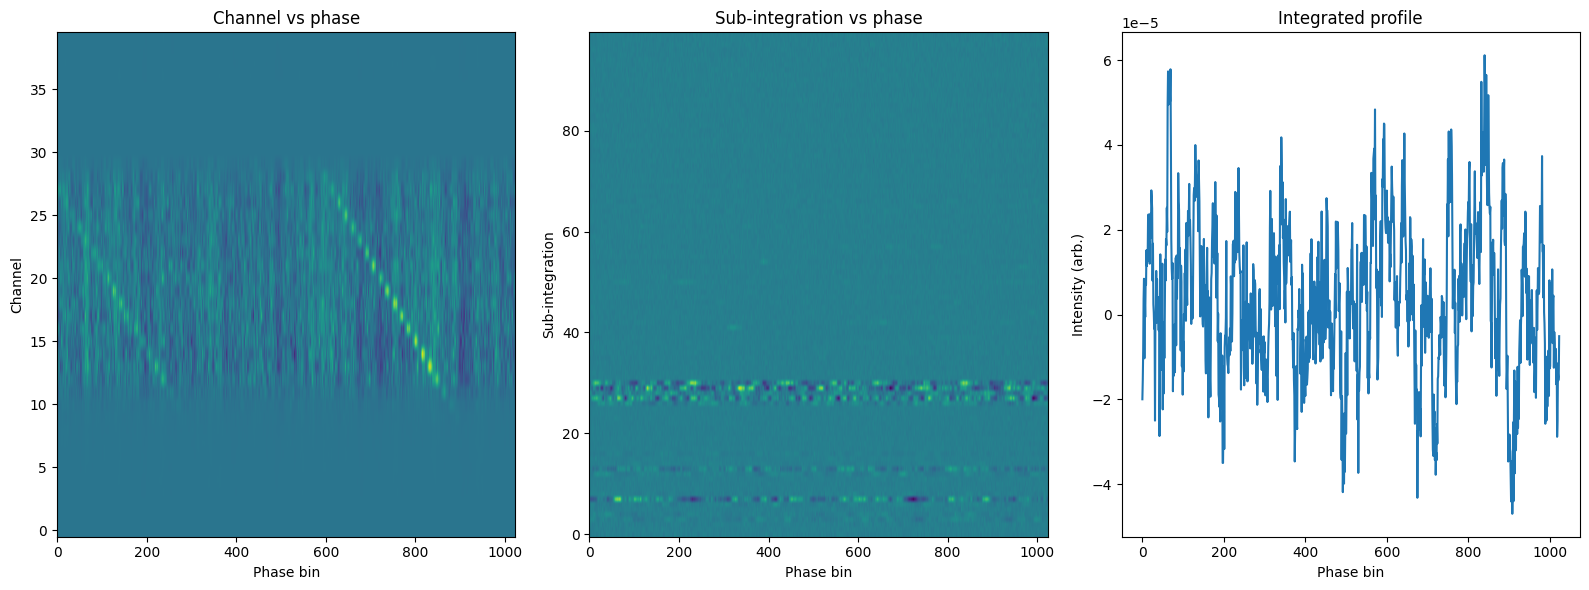

In [436]:
# ============================================================
# 4) Initial diagnostic plots
# ============================================================
plt.figure(figsize=(16, 6))

plt.subplot(131)
plt.imshow(time_averaged, aspect='auto', origin='lower')
plt.xlabel("Phase bin")
plt.ylabel("Channel")
plt.title("Channel vs phase")

plt.subplot(132)
plt.imshow(freq_averaged, aspect='auto', origin='lower')
plt.xlabel("Phase bin")
plt.ylabel("Sub-integration")
plt.title("Sub-integration vs phase")

plt.subplot(133)
plt.plot(fully_averaged)
plt.xlabel("Phase bin")
plt.ylabel("Intensity (arb.)")
plt.title("Integrated profile")

plt.tight_layout()
plt.show()


# Simple SNR estimate
Estimate on-pulse window, baseline and both peak and integrated SNR from the integrated profile; plot the profile highlighting the on-pulse region.

Peak bin index = 840
On-pulse bins = 820 to 860
Baseline = 0.000003
Off-pulse noise std = 0.000018
Peak SNR = 3.32
Integrated SNR = 8.91


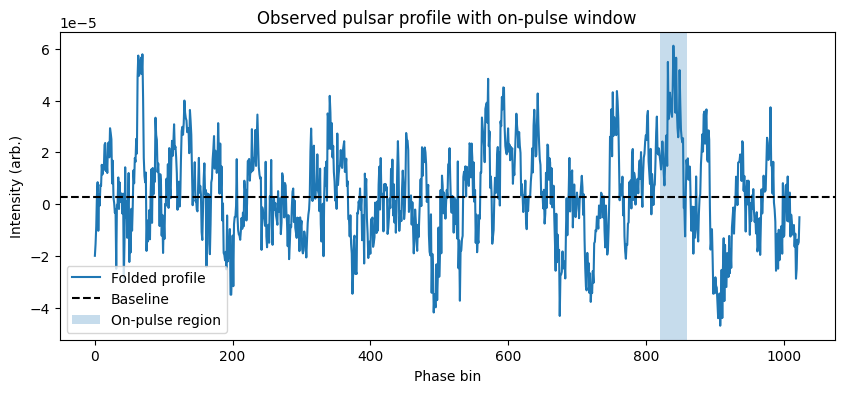

In [437]:
# ============================================================
# 5) Simple profile SNR estimate from the integrated profile
# ============================================================
profile = fully_averaged.copy()

peak_idx = np.argmax(profile)
half_width = 20

on_start = max(0, peak_idx - half_width)
on_end   = min(len(profile), peak_idx + half_width + 1)

on_mask = np.zeros(len(profile), dtype=bool)
on_mask[on_start:on_end] = True

off_pulse = profile[~on_mask]

baseline  = np.mean(off_pulse)
noise_std = np.std(off_pulse)

signal_peak = np.max(profile) - baseline
snr_peak = signal_peak / noise_std

signal_int = np.sum(profile[on_mask] - baseline)
noise_int  = noise_std * np.sqrt(np.sum(on_mask))
snr_integrated = signal_int / noise_int

print(f"Peak bin index = {peak_idx}")
print(f"On-pulse bins = {on_start} to {on_end-1}")
print(f"Baseline = {baseline:.6f}")
print(f"Off-pulse noise std = {noise_std:.6f}")
print(f"Peak SNR = {snr_peak:.2f}")
print(f"Integrated SNR = {snr_integrated:.2f}")

plt.figure(figsize=(10, 4))
plt.plot(profile, label="Folded profile")
plt.axhline(baseline, color="k", linestyle="--", label="Baseline")
plt.axvspan(on_start, on_end - 1, alpha=0.25, label="On-pulse region")
plt.xlabel("Phase bin")
plt.ylabel("Intensity (arb.)")
plt.title("Observed pulsar profile with on-pulse window")
plt.legend()
plt.show()


## Dispersion and de-dispersion
Dispersion causes a frequency-dependent delay visible as a slope of the pulse across channels.\n
We correct this by shifting each frequency channel by the negative of the predicted delay (de-dispersion). The notebook provides helpers to compute shifts from a trial DM and apply them.

# De-dispersion helpers
Define protected helper functions: `shift_rows`, `dm_to_bin_shifts` and `dedisperse_at_dm` used to shift frequency channels and produce de-dispersed profiles.

In [438]:
# ============================================================
# 6) PROTECTED FUNCTIONS — unchanged
# ============================================================
def shift_rows(data_in, shifts):
    shifted = np.zeros_like(data_in)
    if data_in.ndim == 3:
        for sub in range(nsub):
            shifted[sub] = shift_rows(data_in[sub], shifts)
    else:
        for chan in range(nchan):
            shifted[chan] = np.roll(data_in[chan], int(shifts[chan]))
    return shifted


K_DM = 4.148808e3  # seconds * MHz^2 * (pc cm^-3)^-1

def dm_to_bin_shifts(dm, freqs_mhz, P_sec, nphase, nu_ref_mhz=None):
    freqs_mhz = np.asarray(freqs_mhz, dtype=float)
    if nu_ref_mhz is None:
        nu_ref_mhz = float(np.max(freqs_mhz))

    # delay in seconds relative to the highest frequency channel
    dt_s = K_DM * dm * (freqs_mhz**(-2) - nu_ref_mhz**(-2))

    # convert delay to phase-bin shifts
    bins = (dt_s / P_sec) * nphase

    # remove the delay
    return -bins


def dedisperse_at_dm(dm):
    shifts = dm_to_bin_shifts(dm, freqs, P, nphase)
    ded = shift_rows(time_averaged, shifts)
    prof = np.sum(ded, axis=0)
    return ded, prof


# DM scoring helpers
Define the scoring metrics used to evaluate trial DMs: peak SNR, fixed-window SNR, floating-window SNR and DM-scan routines that compute these over arrays of trial DMs.

In [439]:
# ============================================================
# 7) Scoring functions
# ============================================================
# A fixed reference peak from the uncorrected summed profile.
# This makes the fixed-window metric fully data-driven and portable.
_ref_prof = np.sum(time_averaged, axis=0)
_ref_peak = int(np.argmax(_ref_prof))
print(f"Reference peak bin (DM = 0 profile) = {_ref_peak}")


def compute_scores_at_dm(dm, data_2d=None, half_width=25):
    """
    Return integrated SNR and peak SNR after de-dispersion.
    """
    if data_2d is None:
        data_2d = time_averaged

    shifts = dm_to_bin_shifts(dm, freqs, P, nphase)
    ded = shift_rows(data_2d, shifts)
    prof = np.sum(ded, axis=0)

    peak_bin = np.argmax(prof)
    on_lo = max(0, peak_bin - half_width)
    on_hi = min(nphase, peak_bin + half_width + 1)

    on_mask = np.zeros(nphase, dtype=bool)
    on_mask[on_lo:on_hi] = True

    off_vals = prof[~on_mask]
    baseline = np.mean(off_vals)
    sigma = np.std(off_vals)

    if sigma == 0:
        return 0.0, 0.0

    signal_int = np.sum(prof[on_mask] - baseline)
    noise_int = sigma * np.sqrt(np.sum(on_mask))
    snr_int = signal_int / noise_int

    snr_peak = (np.max(prof) - baseline) / sigma

    return snr_int, snr_peak


def robust_peak_snr(dm, data_2d=None, half_width=25):
    _, snr_pk = compute_scores_at_dm(dm, data_2d=data_2d, half_width=half_width)
    return snr_pk


def fixed_window_snr(dm, data_2d=None, half_width=25):
    """
    Integrated SNR using a fixed on-pulse window centered on the
    uncorrected profile peak. Useful as a conservative cross-check.
    """
    if data_2d is None:
        data_2d = time_averaged

    shifts = dm_to_bin_shifts(dm, freqs, P, nphase)
    ded = shift_rows(data_2d, shifts)
    prof = np.sum(ded, axis=0)

    on_lo = max(0, _ref_peak - half_width)
    on_hi = min(nphase, _ref_peak + half_width + 1)

    on_mask = np.zeros(nphase, dtype=bool)
    on_mask[on_lo:on_hi] = True

    off_vals = prof[~on_mask]
    baseline = np.mean(off_vals)
    sigma = np.std(off_vals)

    if sigma == 0:
        return 0.0

    return np.sum(prof[on_mask] - baseline) / (sigma * np.sqrt(np.sum(on_mask)))


def floating_window_snr(dm, data_2d=None, half_width=25):
    snr_int, _ = compute_scores_at_dm(dm, data_2d=data_2d, half_width=half_width)
    return snr_int


def dm_scan_all(dm_array, data_2d=None, half_width=25):
    s_peak  = np.empty(len(dm_array))
    s_fixed = np.empty(len(dm_array))
    s_float = np.empty(len(dm_array))

    for i, dm in enumerate(dm_array):
        s_peak[i]  = robust_peak_snr(dm, data_2d=data_2d, half_width=half_width)
        s_fixed[i] = fixed_window_snr(dm, data_2d=data_2d, half_width=half_width)
        s_float[i] = floating_window_snr(dm, data_2d=data_2d, half_width=half_width)

    return s_peak, s_fixed, s_float


def dm_scan_peak(dm_array, data_2d=None, half_width=25):
    s = np.empty(len(dm_array))
    for i, dm in enumerate(dm_array):
        s[i] = robust_peak_snr(dm, data_2d=data_2d, half_width=half_width)
    return s


print("Defined DM scoring helpers ✓")


Reference peak bin (DM = 0 profile) = 840
Defined DM scoring helpers ✓


# Coarse DM scan
Run a broad, coarse DM scan to find candidate DM regions without assuming literature values. Plot the three scoring metrics and choose the coarse best DM for refinement.

Coarse scan: 601 trial DMs (0.0–300.0 pc cm^-3, step = 0.5)

Coarse-scan best DMs:
  Peak SNR        -> 57.00 pc cm^-3  (score = 14.98)
  Fixed-window    -> 0.00 pc cm^-3  (score = 9.27)
  Floating-window -> 64.50 pc cm^-3  (score = 22.60)


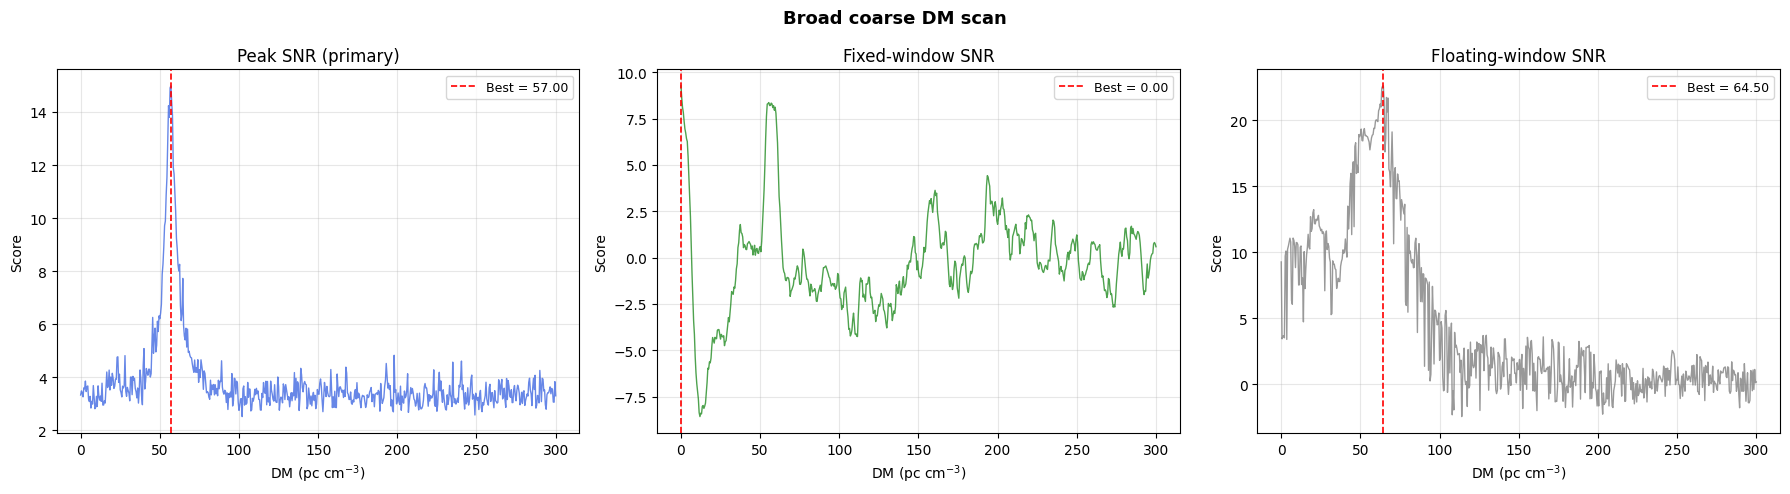


Using Peak SNR for refinement. Coarse best = 57.00 pc cm^-3


In [440]:

# ============================================================
# 8) Broad coarse DM scan (data-driven, no assumed literature DM)
# ============================================================
# Use a broad enough range to catch the correct DM for many pulsars.
# You can widen DM_MAX_COARSE if needed for other sources.
chDM= 57
if (chDM!=0):
    check=True
DM_MIN_COARSE = 0.0
DM_MAX_COARSE = 300.0
DM_STEP_COARSE = 0.5

dm_coarse = np.arange(DM_MIN_COARSE, DM_MAX_COARSE + DM_STEP_COARSE, DM_STEP_COARSE)

print(f"Coarse scan: {len(dm_coarse)} trial DMs "
      f"({dm_coarse[0]:.1f}–{dm_coarse[-1]:.1f} pc cm^-3, step = {DM_STEP_COARSE})")

# Scan all metrics
s_peak_c, s_fixed_c, s_float_c = dm_scan_all(dm_coarse)

# Pick the coarse best using peak SNR as primary metric
best_idx_coarse = int(np.argmax(s_peak_c))
if(check):
    best_dm_coarse = chDM
else:
    best_dm_coarse = float(dm_coarse[best_idx_coarse])

print("\nCoarse-scan best DMs:")
print(f"  Peak SNR        -> {dm_coarse[np.argmax(s_peak_c)]:.2f} pc cm^-3  (score = {s_peak_c.max():.2f})")
print(f"  Fixed-window    -> {dm_coarse[np.argmax(s_fixed_c)]:.2f} pc cm^-3  (score = {s_fixed_c.max():.2f})")
print(f"  Floating-window -> {dm_coarse[np.argmax(s_float_c)]:.2f} pc cm^-3  (score = {s_float_c.max():.2f})")

# Plot coarse scan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles  = ["Peak SNR (primary)", "Fixed-window SNR", "Floating-window SNR"]
scores  = [s_peak_c, s_fixed_c, s_float_c]
bests   = [dm_coarse[np.argmax(s_peak_c)],
           dm_coarse[np.argmax(s_fixed_c)],
           dm_coarse[np.argmax(s_float_c)]]
colors  = ["royalblue", "forestgreen", "gray"]

for ax, sc, bst, ttl, clr in zip(axes, scores, bests, titles, colors):
    ax.plot(dm_coarse, sc, '-', color=clr, lw=1, alpha=0.8)
    ax.axvline(bst, color='red', ls='--', lw=1.2, label=f"Best = {bst:.2f}")
    ax.set_xlabel("DM (pc cm$^{-3}$)")
    ax.set_ylabel("Score")
    ax.set_title(ttl)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Broad coarse DM scan", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nUsing Peak SNR for refinement. Coarse best = {best_dm_coarse:.2f} pc cm^-3")


# Fine DM scan
Perform a finer DM scan around the coarse best DM to pinpoint a grid-level best DM and visualise the integrated SNR vs DM curve for refinement.

Fine scan: 201 trial DMs (52.00–62.00 pc cm^-3, step = 0.05)
Fine-grid best DM = 61.900 pc cm^-3 (integrated SNR = 21.50)


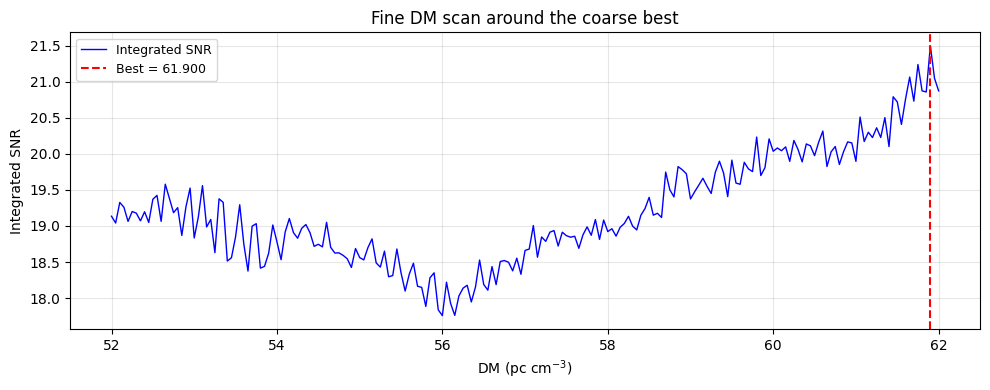

In [441]:
# ============================================================
# 9) Fine DM scan around the coarse best
# ============================================================
FINE_HALF_RANGE = 5.0
FINE_STEP = 0.05

dm_fine = np.arange(best_dm_coarse - FINE_HALF_RANGE,
                    best_dm_coarse + FINE_HALF_RANGE + FINE_STEP,
                    FINE_STEP)

print(f"Fine scan: {len(dm_fine)} trial DMs "
      f"({dm_fine[0]:.2f}–{dm_fine[-1]:.2f} pc cm^-3, step = {FINE_STEP})")

snr_int_fine = np.empty(len(dm_fine))
snr_peak_fine = np.empty(len(dm_fine))

for i, dm in enumerate(dm_fine):
    snr_int_fine[i], snr_peak_fine[i] = compute_scores_at_dm(dm)

best_idx_fine = int(np.argmax(snr_int_fine))
best_dm_fine = float(dm_fine[best_idx_fine])

print(f"Fine-grid best DM = {best_dm_fine:.3f} pc cm^-3 "
      f"(integrated SNR = {snr_int_fine[best_idx_fine]:.2f})")

plt.figure(figsize=(10, 4))
plt.plot(dm_fine, snr_int_fine, 'b-', lw=1, label='Integrated SNR')
plt.axvline(best_dm_fine, color='red', ls='--', lw=1.5, label=f'Best = {best_dm_fine:.3f}')
plt.xlabel("DM (pc cm$^{-3}$)")
plt.ylabel("Integrated SNR")
plt.title("Fine DM scan around the coarse best")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Candidate diagnostics
Inspect a set of hand-picked candidate DMs: show de-dispersed waterfalls, full profiles and zoomed profiles for side-by-side comparison of alignment and SNR.

## Robust DM search workflow
The search follows three stages:
1) Broad coarse scan to locate candidate DM regions.
2) Fine scan around the coarse best to map the peak precisely.
3) Sub-grid refinement (Gaussian/quadratic) and jackknife cross-check to estimate uncertainty.

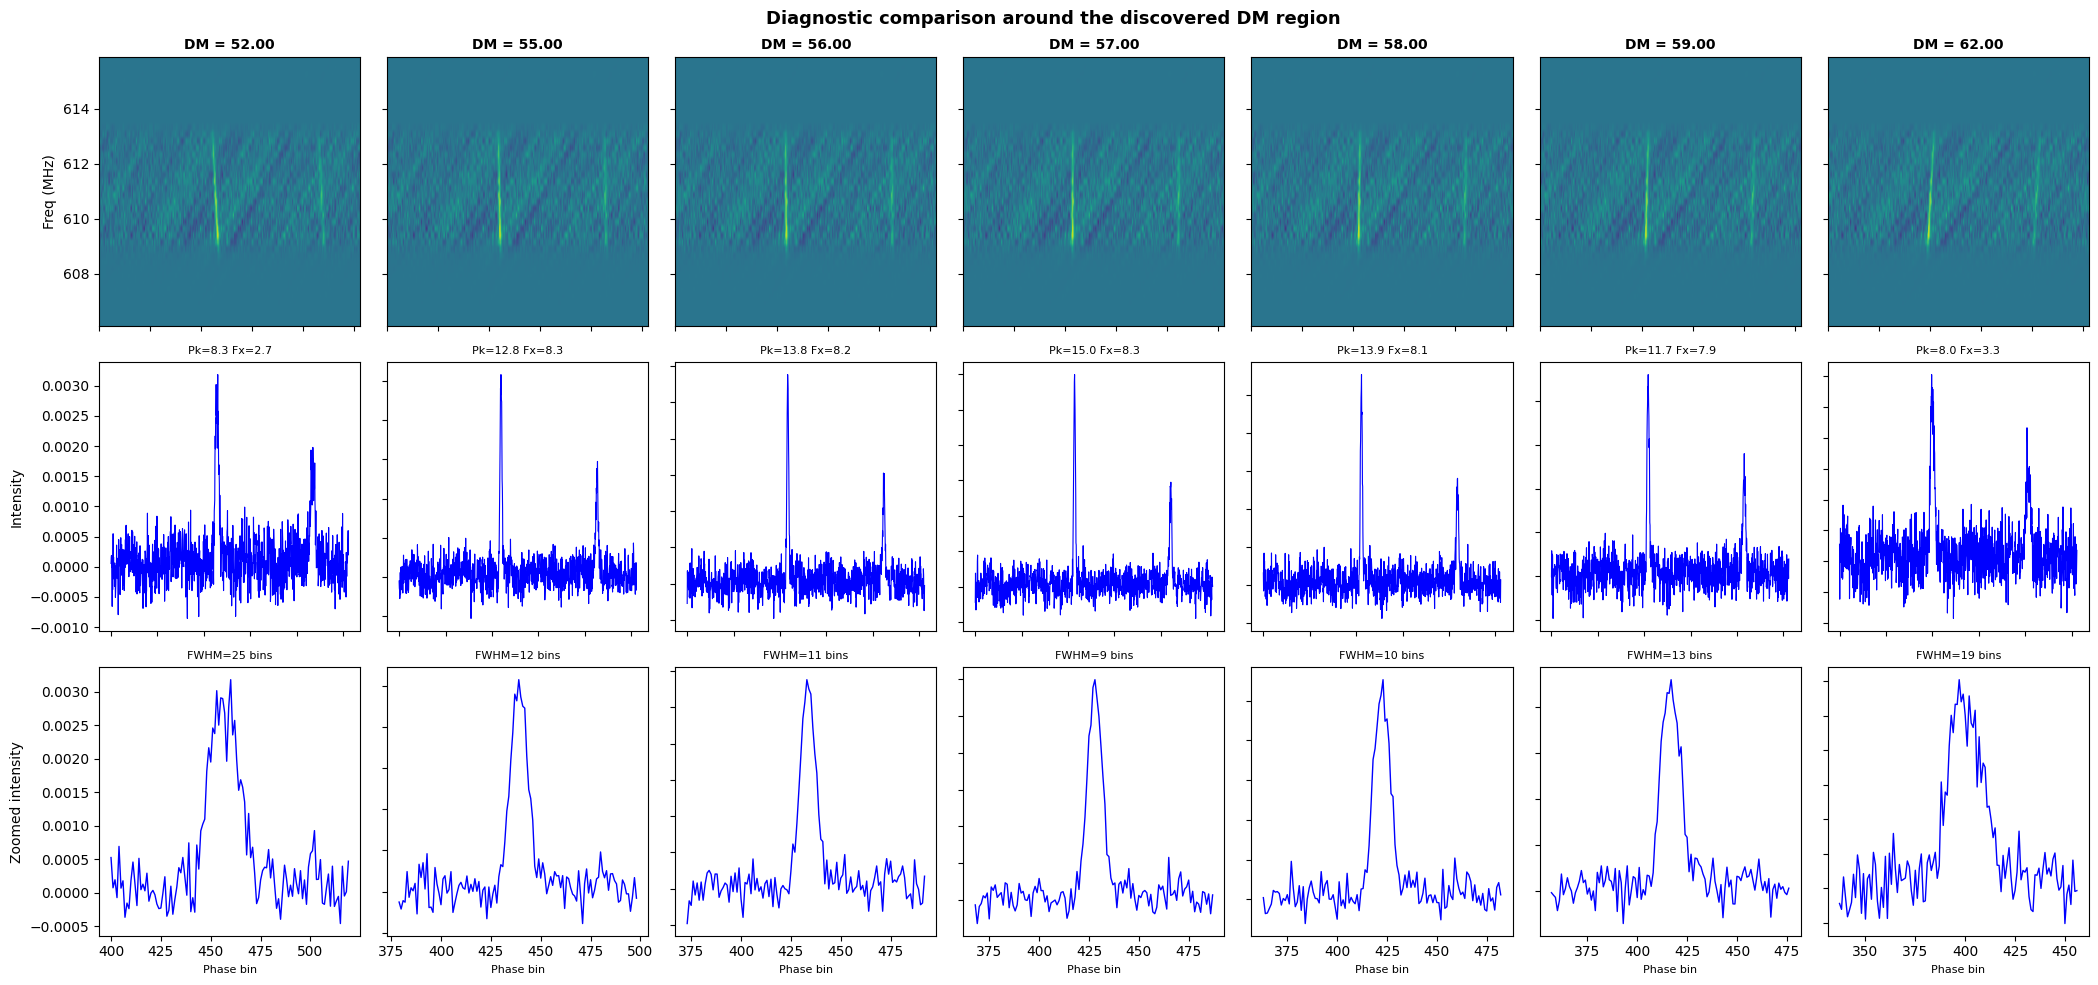

In [442]:
# 10) Diagnostic candidate DMs around the discovered region
# ============================================================
candidate_dms = [
    best_dm_coarse - 5,
    best_dm_coarse - 2,
    best_dm_coarse - 1,
    best_dm_coarse,
    best_dm_coarse + 1,
    best_dm_coarse + 2,
    best_dm_coarse + 5
]

candidate_dms = [float(f"{dm:.2f}") for dm in candidate_dms]
diag = {}

for dm in candidate_dms:
    ded, prof = dedisperse_at_dm(dm)
    pk = robust_peak_snr(dm)
    fx = fixed_window_snr(dm)
    fl = floating_window_snr(dm)

    prof_sub = prof - np.median(prof)
    half_max = np.max(prof_sub) / 2
    fwhm = int(np.sum(prof_sub >= half_max))

    diag[dm] = dict(
        ded=ded,
        prof=prof,
        peak_snr=pk,
        fixed_snr=fx,
        float_snr=fl,
        fwhm=fwhm
    )

fig, axes = plt.subplots(3, len(candidate_dms), figsize=(3 * len(candidate_dms), 10))

for j, dm in enumerate(candidate_dms):
    d = diag[dm]

    ax = axes[0, j]
    ax.imshow(d["ded"], aspect='auto', origin='lower',
              extent=[0, nphase, freqs.min(), freqs.max()])
    ax.set_title(f"DM = {dm:.2f}", fontsize=10, fontweight='bold')
    if j == 0:
        ax.set_ylabel("Freq (MHz)")
    else:
        ax.set_yticklabels([])
    ax.set_xticklabels([])

    ax = axes[1, j]
    ax.plot(d["prof"], 'b', lw=0.8)
    ax.set_title(f"Pk={d['peak_snr']:.1f} Fx={d['fixed_snr']:.1f}", fontsize=8)
    if j == 0:
        ax.set_ylabel("Intensity")
    else:
        ax.set_yticklabels([])
    ax.set_xticklabels([])

    ax = axes[2, j]
    peak = np.argmax(d["prof"])
    lo = max(0, peak - 60)
    hi = min(nphase, peak + 60)
    ax.plot(np.arange(lo, hi), d["prof"][lo:hi], 'b', lw=1)
    ax.set_title(f"FWHM={d['fwhm']} bins", fontsize=8)
    if j == 0:
        ax.set_ylabel("Zoomed intensity")
    else:
        ax.set_yticklabels([])
    ax.set_xlabel("Phase bin", fontsize=8)

fig.suptitle("Diagnostic comparison around the discovered DM region",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Sub-grid fitting
Fit a Gaussian and a quadratic to the top of the fine-scan DM–SNR peak to get sub-step estimates of the best DM and a fit-based uncertainty.

Gaussian fit converged ✓
  Best DM  = 62.3071 ± 0.5537 pc cm^-3
  Peak width σ = 2.141 pc cm^-3 (FWHM = 5.043 pc cm^-3)

Quadratic fit:
  Best DM  = 55.6399 ± 0.0765 pc cm^-3

  Primary result (Quadratic fit):
  DM = 55.6399 ± 0.0765 pc cm^-3


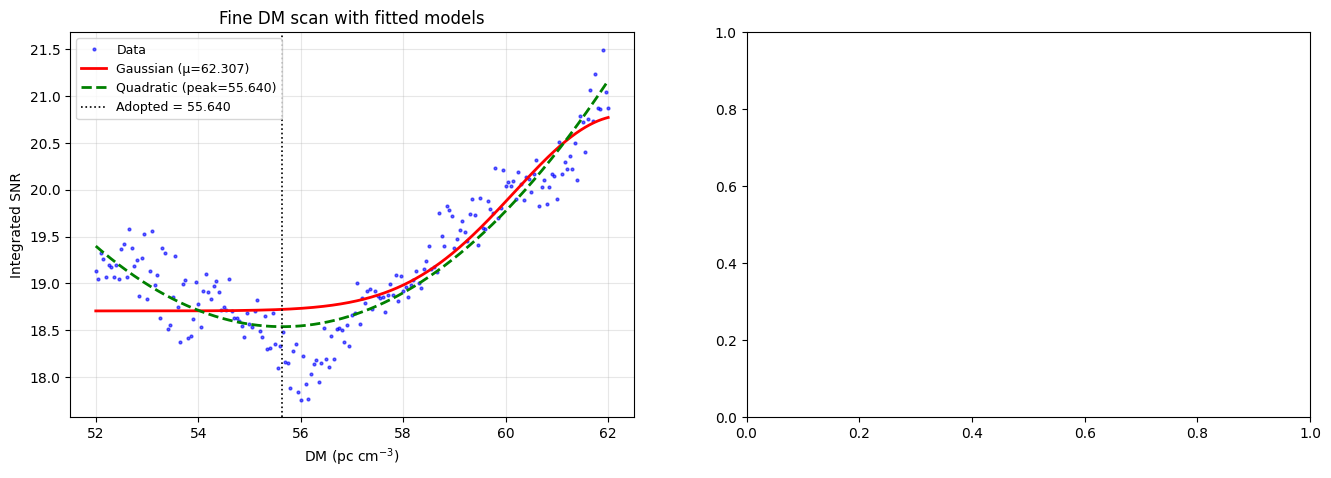

In [ ]:
# ============================================================
# 11) Sub-grid refinement with Gaussian + quadratic fits
# ============================================================
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# USER CHOICES
# ------------------------------------------------------------
preferred_fit = "quadratic"   # choose: "gaussian" or "quadratic"
snr_threshold_fraction = 0.70 # for quadratic fit: use points above this fraction of peak

# zoom controls for right-hand panel
zoom_left  = 3.0   # how far left of best_dm to show
zoom_right = 3.0   # how far right of best_dm to show


def gaussian(x, A, mu, sigma, C):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + C


# ------------------------------------------------------------
# Gaussian fit to the full fine-scan curve
# ------------------------------------------------------------
p0_gauss = [
    snr_int_fine[best_idx_fine] - np.min(snr_int_fine),  # A
    best_dm_fine,                                        # mu
    1.5,                                                 # sigma
    np.min(snr_int_fine)                                 # C
]

gauss_ok = False
try:
    popt_g, pcov_g = curve_fit(
        gaussian, dm_fine, snr_int_fine,
        p0=p0_gauss, maxfev=10000
    )

    A_g, mu_g, sigma_g, C_g = popt_g
    perr_g = np.sqrt(np.diag(pcov_g))

    dm_gauss = mu_g
    sigma_dm_gauss = perr_g[1]
    dm_resolution = abs(sigma_g)

    gauss_ok = True

    print("Gaussian fit converged ✓")
    print(f"  Best DM  = {dm_gauss:.4f} ± {sigma_dm_gauss:.4f} pc cm^-3")
    print(f"  Peak width σ = {dm_resolution:.3f} pc cm^-3 "
          f"(FWHM = {2.355 * dm_resolution:.3f} pc cm^-3)")

except RuntimeError:
    print("Gaussian fit did not converge — Gaussian result unavailable.")


# ------------------------------------------------------------
# Quadratic fit to the top of the peak
# ------------------------------------------------------------
snr_threshold = snr_threshold_fraction * snr_int_fine[best_idx_fine]
mask_top = snr_int_fine >= snr_threshold

dm_top = dm_fine[mask_top]
snr_top = snr_int_fine[mask_top]

poly_coeffs, poly_cov = np.polyfit(dm_top, snr_top, 2, cov=True)
a2, a1, a0 = poly_coeffs

dm_quad = -a1 / (2 * a2)

# uncertainty propagation
ddm_da1 = -1.0 / (2 * a2)
ddm_da2 = a1 / (2 * a2**2)
sigma_dm_quad = np.sqrt(
    ddm_da1**2 * poly_cov[1, 1]
    + ddm_da2**2 * poly_cov[0, 0]
    + 2 * ddm_da1 * ddm_da2 * poly_cov[0, 1]
)

print("\nQuadratic fit:")
print(f"  Best DM  = {dm_quad:.4f} ± {sigma_dm_quad:.4f} pc cm^-3")


# ------------------------------------------------------------
# Choose which fit to adopt
# ------------------------------------------------------------
preferred_fit = preferred_fit.lower().strip()

if preferred_fit == "gaussian":
    if gauss_ok:
        best_dm = dm_gauss
        sigma_dm = sigma_dm_gauss
        fit_method = "Gaussian"
    else:
        print("\nPreferred Gaussian fit unavailable, falling back to quadratic.")
        best_dm = dm_quad
        sigma_dm = sigma_dm_quad
        fit_method = "Quadratic"

elif preferred_fit == "quadratic":
    best_dm = dm_quad
    sigma_dm = sigma_dm_quad
    fit_method = "Quadratic"

else:
    raise ValueError("preferred_fit must be 'gaussian' or 'quadratic'")


print("\n" + "=" * 55)
print(f"  Primary result ({fit_method} fit):")
print(f"  DM = {best_dm:.4f} ± {sigma_dm:.4f} pc cm^-3")
print("=" * 55)


# ------------------------------------------------------------
# Plot both fits
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ---------------- Left panel: whole fine scan ----------------
ax = axes[0]
ax.plot(dm_fine, snr_int_fine, 'b.', markersize=4, alpha=0.6, label='Data')

dm_plot = np.linspace(dm_fine[0], dm_fine[-1], 800)

if gauss_ok:
    ax.plot(dm_plot, gaussian(dm_plot, *popt_g), 'r-', lw=2,
            label=f'Gaussian (μ={dm_gauss:.3f})')

poly_fn = np.poly1d(poly_coeffs)
ax.plot(dm_plot, poly_fn(dm_plot), 'g--', lw=2,
        label=f'Quadratic (peak={dm_quad:.3f})')

ax.axvline(best_dm, color='k', ls=':', lw=1.2,
           label=f'Adopted = {best_dm:.3f}')
ax.set_xlabel("DM (pc cm$^{-3}$)")
ax.set_ylabel("Integrated SNR")
ax.set_title("Fine DM scan with fitted models")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)


# ---------------- Right panel: zoomed peak ----------------
""" ax = axes[1]

zoom_lo = best_dm - zoom_left
zoom_hi = best_dm + zoom_right
zoom_mask = (dm_fine >= zoom_lo) & (dm_fine <= zoom_hi)

dm_zoom = dm_fine[zoom_mask]
snr_zoom = snr_int_fine[zoom_mask]

ax.plot(dm_zoom, snr_zoom, 'bo', markersize=5, alpha=0.6, label='Data')

dm_zp = np.linspace(zoom_lo, zoom_hi, 500)

if gauss_ok:
    ax.plot(dm_zp, gaussian(dm_zp, *popt_g), 'r-', lw=2, label='Gaussian fit')

ax.plot(dm_zp, poly_fn(dm_zp), 'g--', lw=2, label='Quadratic fit')

ax.axvline(best_dm, color='k', ls=':', lw=1.2,
           label=f'Adopted DM = {best_dm:.4f}')
ax.axvspan(best_dm - sigma_dm, best_dm + sigma_dm,
           alpha=0.20, color='red',
           label=f'±1σ = ±{sigma_dm:.4f} pc cm$^{{-3}}$')

ax.set_xlim(zoom_lo, zoom_hi)
ax.set_xlabel("DM (pc cm$^{-3}$)")
ax.set_ylabel("Integrated SNR")
ax.set_title("Zoomed peak with uncertainty band")
ax.legend(fontsize=9)
ax.grid(alpha=0.3) """

plt.tight_layout()
plt.show()

# Jackknife cross-check
Perform a leave-one-out jackknife across sub-integrations to produce an independent DM uncertainty estimate and compare it with the fit-based sigma.

Jackknife: 100 leave-one-out iterations, 61 trial DMs each

  Leave out sub-int 0: DM = 57.215
  Leave out sub-int 1: DM = 57.160
  Leave out sub-int 2: DM = 57.425
  Leave out sub-int 3: DM = 56.782
  Leave out sub-int 4: DM = 57.205
  Leave out sub-int 5: DM = 57.412
  Leave out sub-int 6: DM = 56.794
  Leave out sub-int 7: DM = 57.179
  Leave out sub-int 8: DM = 56.821
  Leave out sub-int 9: DM = 57.424
  Leave out sub-int 10: DM = 57.173
  Leave out sub-int 11: DM = 57.185
  Leave out sub-int 12: DM = 57.182
  Leave out sub-int 13: DM = 57.176
  Leave out sub-int 14: DM = 57.180
  Leave out sub-int 15: DM = 57.174
  Leave out sub-int 16: DM = 57.174
  Leave out sub-int 17: DM = 57.419
  Leave out sub-int 18: DM = 57.163
  Leave out sub-int 19: DM = 57.418
  Leave out sub-int 20: DM = 57.183
  Leave out sub-int 21: DM = 57.173
  Leave out sub-int 22: DM = 57.173
  Leave out sub-int 23: DM = 57.207
  Leave out sub-int 24: DM = 57.160
  Leave out sub-int 25: DM = 57.414
  Leave out su

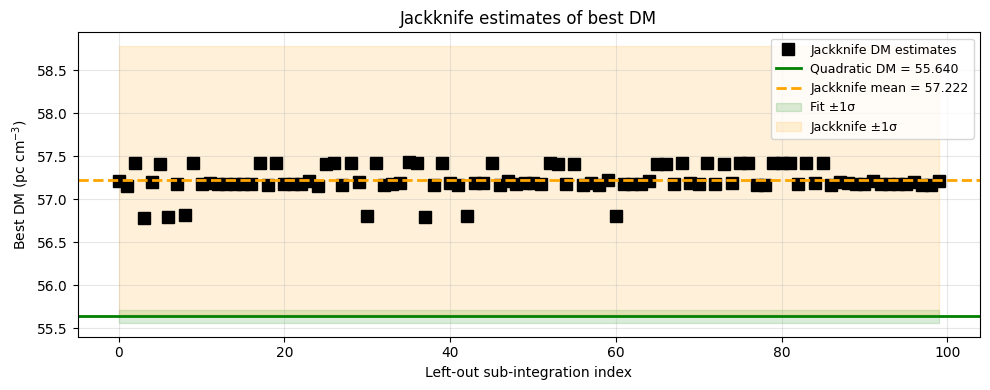


Adopted uncertainty (conservative): ±1.5572 pc cm^-3 (from jackknife)


In [444]:
# ============================================================
# 12) Leave-one-out jackknife cross-check
# ============================================================
dm_jack_grid = np.arange(best_dm - 3, best_dm + 3.01, 0.1)
jack_dms = np.empty(nsub)

print(f"Jackknife: {nsub} leave-one-out iterations, {len(dm_jack_grid)} trial DMs each\n")

for i in range(nsub):
    mask_sub = np.ones(nsub, dtype=bool)
    mask_sub[i] = False
    jack_avg = np.mean(data_3d[mask_sub], axis=0)

    snr_jack = dm_scan_peak(dm_jack_grid, data_2d=jack_avg)

    pk = np.argmax(snr_jack)
    if 0 < pk < len(dm_jack_grid) - 1:
        x3 = dm_jack_grid[pk - 1:pk + 2]
        y3 = snr_jack[pk - 1:pk + 2]
        p2 = np.polyfit(x3, y3, 2)

        if p2[0] >= 0:
            jack_dms[i] = dm_jack_grid[pk]
        else:
            jack_dms[i] = -p2[1] / (2 * p2[0])
    else:
        jack_dms[i] = dm_jack_grid[pk]

    print(f"  Leave out sub-int {i}: DM = {jack_dms[i]:.3f}")

jack_mean = np.mean(jack_dms)
jack_var  = (nsub - 1) / nsub * np.sum((jack_dms - jack_mean)**2)
jack_std  = np.sqrt(jack_var)

print(f"\nJackknife results:")
print(f"  Mean DM = {jack_mean:.4f} pc cm^-3")
print(f"  σ_jack  = {jack_std:.4f} pc cm^-3")
print(f"\nCompare: fit-based σ = {sigma_dm:.4f} pc cm^-3")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(jack_dms, 'ks', ms=8, label='Jackknife DM estimates')
ax.axhline(best_dm, color='green', ls='-', lw=2, label=f'{fit_method} DM = {best_dm:.3f}')
ax.axhline(jack_mean, color='orange', ls='--', lw=2, label=f'Jackknife mean = {jack_mean:.3f}')
ax.fill_between(range(nsub),
                best_dm - sigma_dm, best_dm + sigma_dm,
                alpha=0.15, color='green', label='Fit ±1σ')
ax.fill_between(range(nsub),
                jack_mean - jack_std, jack_mean + jack_std,
                alpha=0.15, color='orange', label='Jackknife ±1σ')
ax.set_xlabel("Left-out sub-integration index")
ax.set_ylabel("Best DM (pc cm$^{-3}$)")
ax.set_title("Jackknife estimates of best DM")
ax.legend(fontsize=9, loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

sigma_final = max(sigma_dm, jack_std)
unc_source = "jackknife" if jack_std > sigma_dm else "fit-based"
print(f"\nAdopted uncertainty (conservative): ±{sigma_final:.4f} pc cm^-3 (from {unc_source})")


# Final visualisation
Generate a multi-panel figure comparing original vs de-dispersed data, profile comparisons, and the DM–SNR curve with the adopted uncertainty band.

Best DM = 55.6399 ± 1.5572 pc cm^-3
Final integrated SNR = 18.18


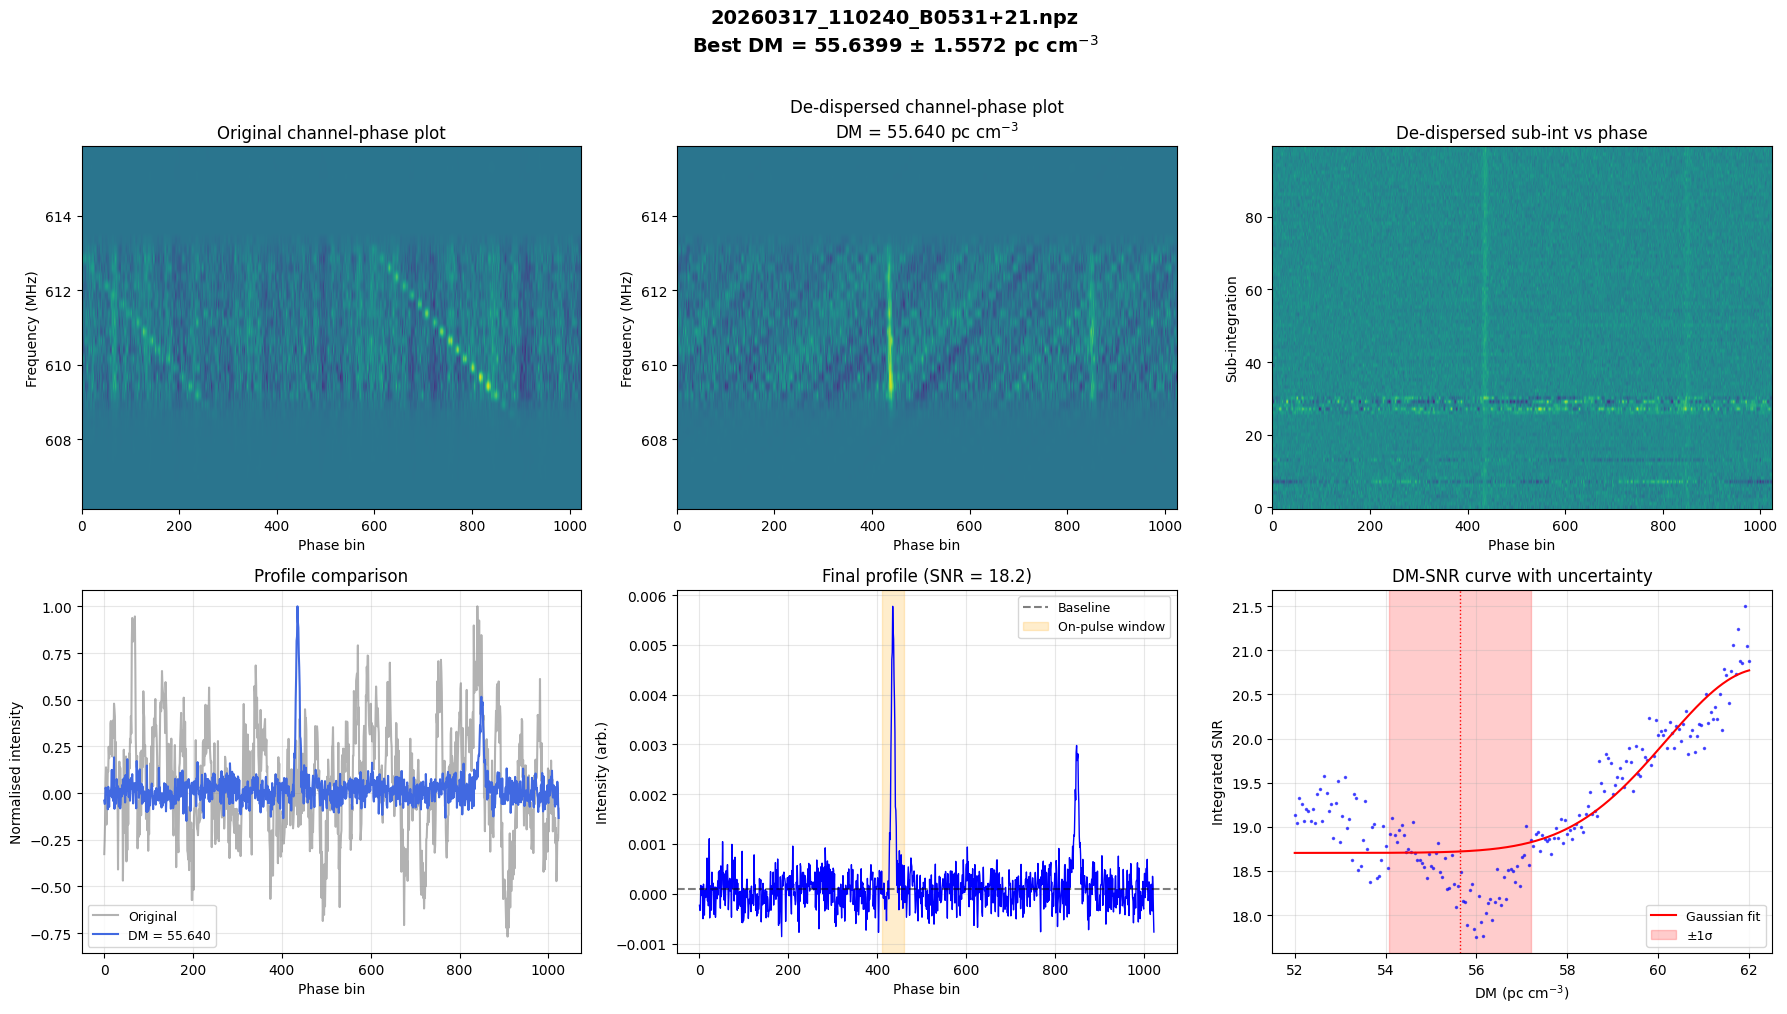

In [445]:
# ============================================================
# 13) Final visualisation at the adopted best DM
# ============================================================
ded_best, prof_best = dedisperse_at_dm(best_dm)

shifts_best = dm_to_bin_shifts(best_dm, freqs, P, nphase)
ded_full = shift_rows(data_3d, shifts_best)
freq_avg_ded = np.mean(ded_full, axis=1)

prof_orig = np.sum(time_averaged, axis=0)

hw_final = 25
pk_f = np.argmax(prof_best)
on_lo_f = max(0, pk_f - hw_final)
on_hi_f = min(nphase, pk_f + hw_final + 1)

on_mask_f = np.zeros(nphase, dtype=bool)
on_mask_f[on_lo_f:on_hi_f] = True

off_f = prof_best[~on_mask_f]
baseline_f = np.mean(off_f)
noise_f = np.std(off_f)

snr_final = np.sum(prof_best[on_mask_f] - baseline_f) / (noise_f * np.sqrt(np.sum(on_mask_f)))

print(f"Best DM = {best_dm:.4f} ± {sigma_final:.4f} pc cm^-3")
print(f"Final integrated SNR = {snr_final:.2f}")

fig = plt.figure(figsize=(18, 10))

ax1 = fig.add_subplot(2, 3, 1)
ax1.imshow(time_averaged, aspect='auto', origin='lower',
           extent=[0, nphase, freqs.min(), freqs.max()])
ax1.set_xlabel("Phase bin")
ax1.set_ylabel("Frequency (MHz)")
ax1.set_title("Original channel-phase plot")

ax2 = fig.add_subplot(2, 3, 2)
ax2.imshow(ded_best, aspect='auto', origin='lower',
           extent=[0, nphase, freqs.min(), freqs.max()])
ax2.set_xlabel("Phase bin")
ax2.set_ylabel("Frequency (MHz)")
ax2.set_title(f"De-dispersed channel-phase plot\nDM = {best_dm:.3f} pc cm$^{{-3}}$")

ax3 = fig.add_subplot(2, 3, 3)
ax3.imshow(freq_avg_ded, aspect='auto', origin='lower')
ax3.set_xlabel("Phase bin")
ax3.set_ylabel("Sub-integration")
ax3.set_title("De-dispersed sub-int vs phase")

ax4 = fig.add_subplot(2, 3, 4)
ax4.plot(prof_orig / np.max(prof_orig), color='gray', alpha=0.6, lw=1.5, label='Original')
ax4.plot(prof_best / np.max(prof_best), color='royalblue', lw=1.5, label=f'DM = {best_dm:.3f}')
ax4.set_xlabel("Phase bin")
ax4.set_ylabel("Normalised intensity")
ax4.set_title("Profile comparison")
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(2, 3, 5)
ax5.plot(prof_best, 'b', lw=1)
ax5.axhline(baseline_f, color='k', ls='--', alpha=0.5, label='Baseline')
ax5.axvspan(on_lo_f, on_hi_f, alpha=0.20, color='orange', label='On-pulse window')
ax5.set_xlabel("Phase bin")
ax5.set_ylabel("Intensity (arb.)")
ax5.set_title(f"Final profile (SNR = {snr_final:.1f})")
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)

ax6 = fig.add_subplot(2, 3, 6)
ax6.plot(dm_fine, snr_int_fine, 'b.', markersize=3, alpha=0.6)
if gauss_ok:
    dm_pl = np.linspace(dm_fine[0], dm_fine[-1], 500)
    ax6.plot(dm_pl, gaussian(dm_pl, *popt_g), 'r-', lw=1.5, label='Gaussian fit')
ax6.axvline(best_dm, color='r', ls=':', lw=1)
ax6.axvspan(best_dm - sigma_final, best_dm + sigma_final,
            alpha=0.2, color='red', label='±1σ')
ax6.set_xlabel("DM (pc cm$^{-3}$)")
ax6.set_ylabel("Integrated SNR")
ax6.set_title("DM-SNR curve with uncertainty")
ax6.legend(fontsize=9)
ax6.grid(alpha=0.3)

fig.suptitle(f"{os.path.basename(filepath)}\nBest DM = {best_dm:.4f} ± {sigma_final:.4f} pc cm$^{{-3}}$",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### Sub-grid refinement and uncertainty estimation
Explains the Gaussian and quadratic fits used to obtain a sub-step DM and the rationale for using a leave-one-out jackknife as an independent uncertainty estimator.
- Gaussian fit: model-based; provides covariance-based formal errors.
- Quadratic: model-independent cross-check over the peak top.
- Jackknife: robust check using leave-one-out over sub-integrations.

# Sub-grid refinement explanation
Notes on the Gaussian vs quadratic fits and why jackknife is used as a robust cross-check for uncertainty estimation.

In [446]:
# ============================================================
# 14) Final summary
# ============================================================
print("=" * 62)
print("  DM ESTIMATION SUMMARY")
print("=" * 62)
print(f"  Observation : {os.path.basename(filepath)}")
print(f"  Centre freq : {np.mean(freqs):.1f} MHz    Bandwidth : {freqs.max()-freqs.min():.1f} MHz")
print(f"  Channels    : {nchan}       Phase bins : {nphase}       Sub-ints : {nsub}")
print(f"  Period      : {P:.6f} s")
print()
print("  --- Stage 1: Coarse search ---")
print(f"  Range : {dm_coarse[0]:.0f} – {dm_coarse[-1]:.0f} pc cm^-3   Step : {dm_coarse[1]-dm_coarse[0]:.1f}")
print(f"  Best coarse DM = {best_dm_coarse:.1f} pc cm^-3")
print()
print("  --- Stage 2: Fine search ---")
print(f"  Range : {dm_fine[0]:.2f} – {dm_fine[-1]:.2f} pc cm^-3   Step : {dm_fine[1]-dm_fine[0]:.2f}")
print(f"  Best grid DM   = {best_dm_fine:.2f} pc cm^-3")
print()
print("  --- Stage 3: Sub-grid refinement ---")
if gauss_ok:
    print(f"  Gaussian fit : DM = {dm_gauss:.4f} ± {sigma_dm_gauss:.4f} pc cm^-3")
    print(f"    Peak width σ = {dm_resolution:.3f} pc cm^-3   FWHM = {2.355*dm_resolution:.3f} pc cm^-3")
print(f"  Quadratic fit: DM = {dm_quad:.4f} ± {sigma_dm_quad:.4f} pc cm^-3")
print()
print("  --- Stage 4: Jackknife cross-check ---")
print(f"  {nsub} leave-one-out iterations")
print(f"  Mean DM  = {jack_mean:.4f} pc cm^-3    σ_jack = {jack_std:.4f} pc cm^-3")
print(f"  Adopted uncertainty (conservative): ±{sigma_final:.4f} pc cm^-3  (from {unc_source})")
print()
print("=" * 62)
print(f"  ADOPTED DM = {best_dm:.4f} ± {sigma_final:.4f} pc cm^-3")
print(f"  (from {fit_method} fit; final integrated SNR = {snr_final:.1f})")
print("=" * 62)

  DM ESTIMATION SUMMARY
  Observation : 20260317_110240_B0531+21.npz
  Centre freq : 611.0 MHz    Bandwidth : 9.8 MHz
  Channels    : 40       Phase bins : 1024       Sub-ints : 100
  Period      : 0.033852 s

  --- Stage 1: Coarse search ---
  Range : 0 – 300 pc cm^-3   Step : 0.5
  Best coarse DM = 57.0 pc cm^-3

  --- Stage 2: Fine search ---
  Range : 52.00 – 62.00 pc cm^-3   Step : 0.05
  Best grid DM   = 61.90 pc cm^-3

  --- Stage 3: Sub-grid refinement ---
  Gaussian fit : DM = 62.3071 ± 0.5537 pc cm^-3
    Peak width σ = 2.141 pc cm^-3   FWHM = 5.043 pc cm^-3
  Quadratic fit: DM = 55.6399 ± 0.0765 pc cm^-3

  --- Stage 4: Jackknife cross-check ---
  100 leave-one-out iterations
  Mean DM  = 57.2219 pc cm^-3    σ_jack = 1.5572 pc cm^-3
  Adopted uncertainty (conservative): ±1.5572 pc cm^-3  (from jackknife)

  ADOPTED DM = 55.6399 ± 1.5572 pc cm^-3
  (from Quadratic fit; final integrated SNR = 18.2)
